In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, recall_score, f1_score, precision_score,classification_report, calinski_harabasz_score, davies_bouldin_score, silhouette_score,confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('tmdb_5000_movies.csv',encoding_errors='ignore')
df.head()

,budget,id,language,popularity,release_date,revenue,runtime,status,title,vote_avg,...,genres_1,genres_2,genres_3,genres_4,pro_com_1,pro_com_2,pro_com_3,pro_com_4,pro_coun_1,pro_coun_2
0,237000000,19995,English,150.437577,10-12-2009,2787965087,02:42,Released,Avatar,7.2,...,Action,Adventure,Fantasy,Science Fiction,Ingenious Film Partners,Twentieth Century Fox Film Corporation,Dune Entertainment,Lightstorm Entertainment,United States of America,United Kingdom
1,300000000,285,English,139.082615,19-05-2007,961000000,02:49,Released,Pirates of the Caribbean: At World's End,6.9,...,Adventure,Fantasy,Action,NaN,Walt Disney Pictures,Jerry Bruckheimer Films,Second Mate Productions,NaN,United States of America,NaN
2,245000000,206647,English,107.376788,26-10-2015,880674609,02:28,Released,Spectre,6.3,...,Action,Adventure,Crime,NaN,Columbia Pictures,Danjaq,B24,NaN,United Kingdom,United States of America
3,250000000,49026,English,112.312950,16-07-2012,1084939099,02:45,Released,The Dark Knight Rises,7.6,...,Action,Crime,Drama,Thriller,Legendary Pictures,Warner Bros.,DC Entertainment,Syncopy,United States of America,NaN
4,260000000,49529,English,43.926995,07-03-2012,284139100,02:12,Released,John Carter,6.1,...,Action,Adventure,Science Fiction,NaN,Walt Disney Pictures,NaN,NaN,NaN,United States of America,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4770 entries, 0 to 4769
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        4770 non-null   int64  
 1   id            4770 non-null   int64  
 2   language      4770 non-null   object 
 3   popularity    4770 non-null   float64
 4   release_date  4770 non-null   object 
 5   revenue       4770 non-null   int64  
 6   runtime       4770 non-null   object 
 7   status        4770 non-null   object 
 8   title         4770 non-null   object 
 9   vote_avg      4770 non-null   float64
 10  vote_count    4770 non-null   int64  
 11  genres_1      3967 non-null   object 
 12  genres_2      3311 non-null   object 
 13  genres_3      2121 non-null   object 
 14  genres_4      804 non-null    object 
 15  pro_com_1     4770 non-null   object 
 16  pro_com_2     3384 non-null   object 
 17  pro_com_3     2324 non-null   object 
 18  pro_com_4     1408 non-null 

In [4]:
df['id']=df['id'].astype("object")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4770 entries, 0 to 4769
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        4770 non-null   int64  
 1   id            4770 non-null   object 
 2   language      4770 non-null   object 
 3   popularity    4770 non-null   float64
 4   release_date  4770 non-null   object 
 5   revenue       4770 non-null   int64  
 6   runtime       4770 non-null   object 
 7   status        4770 non-null   object 
 8   title         4770 non-null   object 
 9   vote_avg      4770 non-null   float64
 10  vote_count    4770 non-null   int64  
 11  genres_1      3967 non-null   object 
 12  genres_2      3311 non-null   object 
 13  genres_3      2121 non-null   object 
 14  genres_4      804 non-null    object 
 15  pro_com_1     4770 non-null   object 
 16  pro_com_2     3384 non-null   object 
 17  pro_com_3     2324 non-null   object 
 18  pro_com_4     1408 non-null 

In [5]:
df.isnull().sum()

budget             0
id                 0
language           0
popularity         0
release_date       0
revenue            0
runtime            0
status             0
title              0
vote_avg           0
vote_count         0
genres_1         803
genres_2        1459
genres_3        2649
genres_4        3966
pro_com_1          0
pro_com_2       1386
pro_com_3       2446
pro_com_4       3362
pro_coun_1       150
pro_coun_2      3523
dtype: int64

In [6]:
cols = df.columns.tolist()

In [7]:
null_cols_replaced = {}
for i in cols:
    if df[i].isnull().sum() > 0:
        n_c = df[i].isnull().sum()
        df[i] = df[i].fillna('NA')
        null_cols_replaced[i] = n_c
print("Columns Replaced with 'NA' with null counts") 
for col,count in null_cols_replaced.items():
    print(f"{col} : {count}")
print('\n')
df.isnull().sum()

Columns Replaced with 'NA' with null counts
genres_1 : 803
genres_2 : 1459
genres_3 : 2649
genres_4 : 3966
pro_com_2 : 1386
pro_com_3 : 2446
pro_com_4 : 3362
pro_coun_1 : 150
pro_coun_2 : 3523




budget          0
id              0
language        0
popularity      0
release_date    0
revenue         0
runtime         0
status          0
title           0
vote_avg        0
vote_count      0
genres_1        0
genres_2        0
genres_3        0
genres_4        0
pro_com_1       0
pro_com_2       0
pro_com_3       0
pro_com_4       0
pro_coun_1      0
pro_coun_2      0
dtype: int64

In [8]:
df.to_csv('Cleaned Movies Data.csv', index = False)

In [9]:
final_df = df.copy()

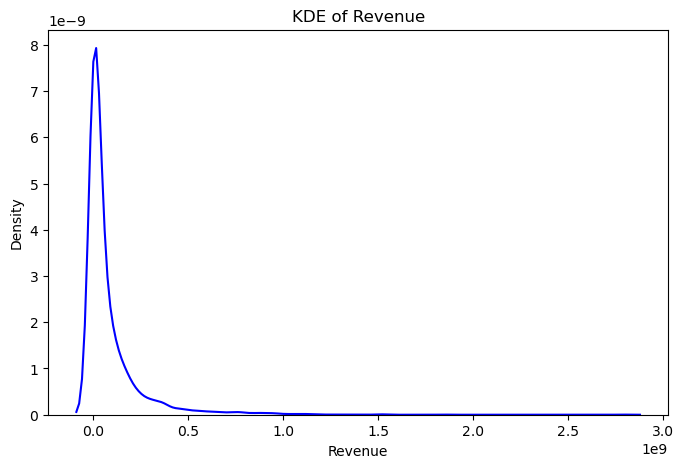

In [10]:
#CLT
plt.figure(figsize = (8,5))
sns.kdeplot(final_df['revenue'],color = 'Blue')
plt.title('KDE of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Density')
plt.show()

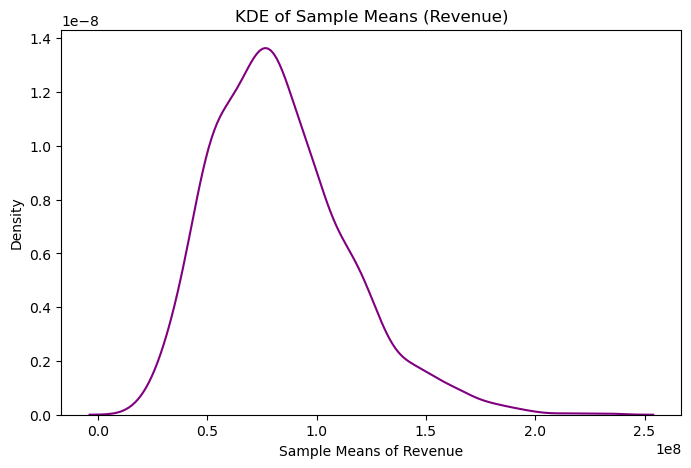

In [11]:
sample_size = 30
num_samples = 1300
sample_means = [final_df['revenue'].sample(sample_size,random_state=i,replace = True).mean() for i in range(num_samples)]

plt.figure(figsize = (8,5))
sns.kdeplot(sample_means,color = 'purple')
plt.title('KDE of Sample Means (Revenue)')
plt.xlabel('Sample Means of Revenue')
plt.ylabel('Density')
plt.show()

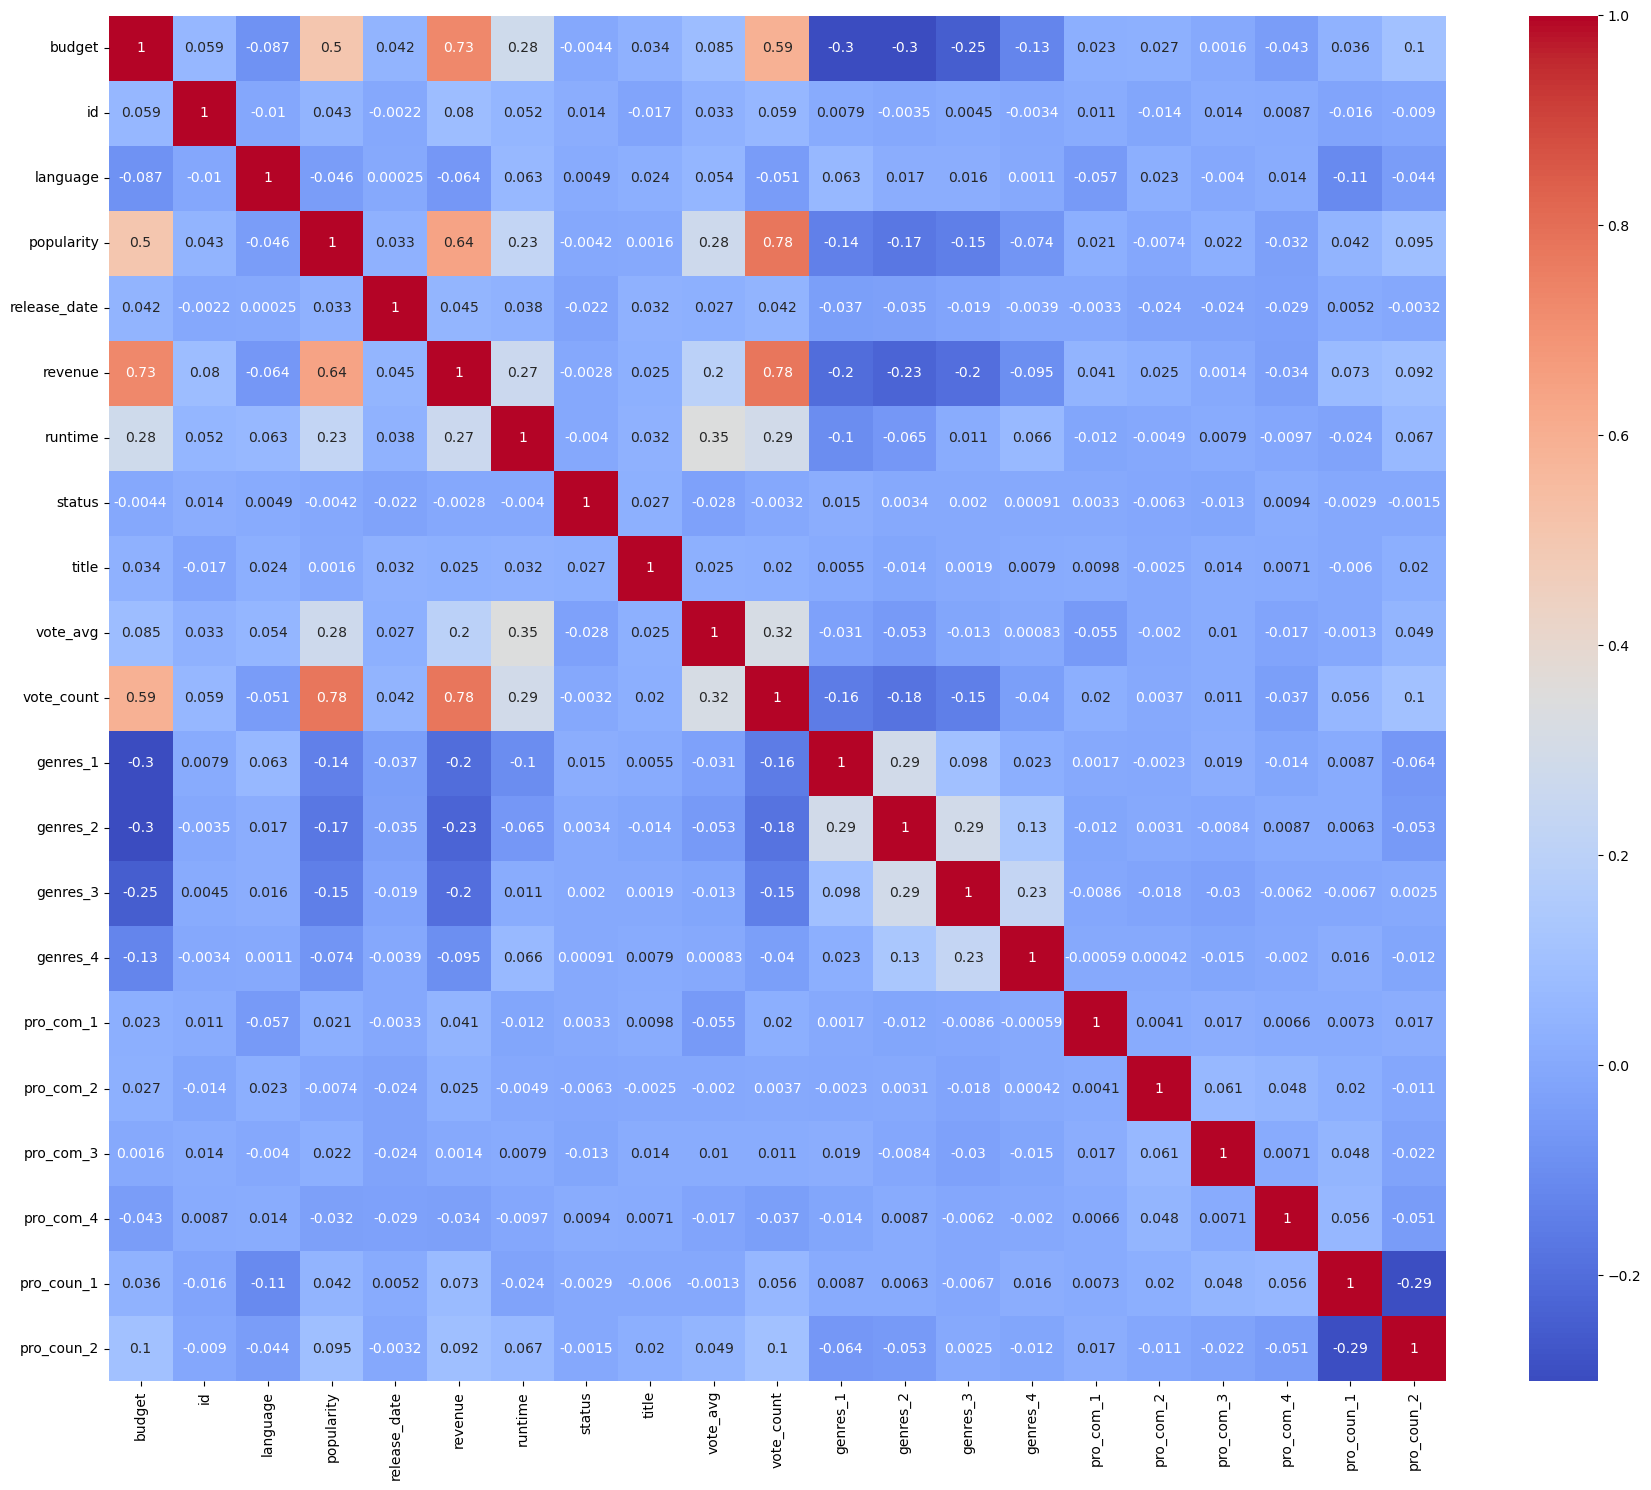

In [12]:
l_e = LabelEncoder()
for col in final_df.select_dtypes(include = 'object').columns:
    final_df[col] = l_e.fit_transform(final_df[col].astype(str))

fig,ax = plt.subplots(1,1,figsize=(18,15))
sns.heatmap(final_df.corr() , annot = True, cmap = 'coolwarm',ax=ax)
plt.tight_layout()
plt.show()

In [13]:
cols_scale = final_df.columns
scaler = StandardScaler()
scaled_df = scaler.fit_transform(final_df)
scaled_df = pd.DataFrame(scaled_df,columns = cols_scale)
scaled_df

,budget,id,language,popularity,release_date,revenue,runtime,status,title,vote_avg,...,genres_1,genres_2,genres_3,genres_4,pro_com_1,pro_com_2,pro_com_3,pro_com_4,pro_coun_1,pro_coun_2
0,5.093661,-0.471684,-0.152549,4.040865,-0.580756,16.569680,2.734457,-0.005473,-1.457661,0.950178,...,-1.234450,-1.542515,-0.963289,1.000852,-0.466926,1.454525,-1.445340,-0.524554,0.560265,1.843969
1,6.638279,0.054104,-0.152549,3.684619,0.448469,5.379028,3.035612,-0.005473,0.178825,0.688061,...,-1.039156,-0.281662,-2.738235,0.165861,1.156022,-0.359258,1.041472,0.150361,0.560265,-0.273212
2,5.289803,-0.417217,-0.152549,2.689894,1.315129,4.887014,2.031763,-0.005473,0.562512,0.163828,...,-1.234450,-1.542515,-1.850762,0.165861,-1.340239,-1.322831,-2.375421,0.150361,0.510723,1.940204
3,5.412391,0.695362,-0.152549,2.844759,0.108561,6.138189,2.885035,-0.005473,0.874259,1.299667,...,-1.234450,-1.002150,-1.407026,1.418348,-0.265004,1.612245,-1.682807,1.714936,0.560265,-0.273212
4,5.657569,0.714244,-0.152549,0.699248,-1.015669,1.233074,1.228684,-0.005473,-0.360373,-0.010917,...,-1.234450,-1.542515,0.811656,0.165861,1.156022,0.229728,0.183951,0.150361,0.560265,-0.273212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4765,-0.711652,1.516725,7.481438,-0.231204,-1.283796,-0.494853,-1.331131,-0.005473,-0.906110,0.425944,...,1.304380,0.799069,0.367920,0.165861,-1.340239,0.229728,0.183951,0.150361,-0.579209,1.940204
4766,-0.716825,1.094061,-0.152549,-0.658739,1.330963,-0.507354,-1.130361,-0.005473,0.029128,-0.185661,...,1.304380,0.799069,0.367920,0.165861,1.284747,0.229728,0.183951,0.150361,-0.480125,-0.273212
4767,-0.717046,-0.255269,-0.152549,-0.633580,-0.214457,-0.507354,0.626374,-0.005473,0.483304,0.775433,...,1.304380,0.799069,0.367920,0.165861,-0.815241,0.210013,0.183951,0.150361,0.560265,-0.273212
4768,-0.717046,-1.177577,-0.152549,-0.652011,-1.403080,-0.507354,-0.477859,-0.005473,0.447697,-0.360406,...,1.304380,0.799069,0.367920,0.165861,1.284747,0.229728,0.183951,0.150361,0.560265,-2.390392


# Revenue Amount Prediction

In [14]:
# Predict Revenue

features = ['budget','popularity','runtime','vote_avg','vote_count']
x = scaled_df[features]
y = scaled_df['revenue']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(x, y, test_size=0.3, random_state=1)

model_revenue = LinearRegression()
model_revenue.fit(X_train_r, y_train_r)
# Predict on test data
y_pred_r = model_revenue.predict(X_test_r)

# Evaluate model
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
RMSE = mean_squared_error(y_test_r,y_pred_r,squared = False)
r2 = r2_score(y_test_r, y_pred_r)
print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("R2 Score:", round(r2,2))
print("RMSE:", round(RMSE,2))

Mean Absolute Error (MAE): 0.28
Mean Squared Error (MSE): 0.31
R2 Score: 0.71
RMSE: 0.56


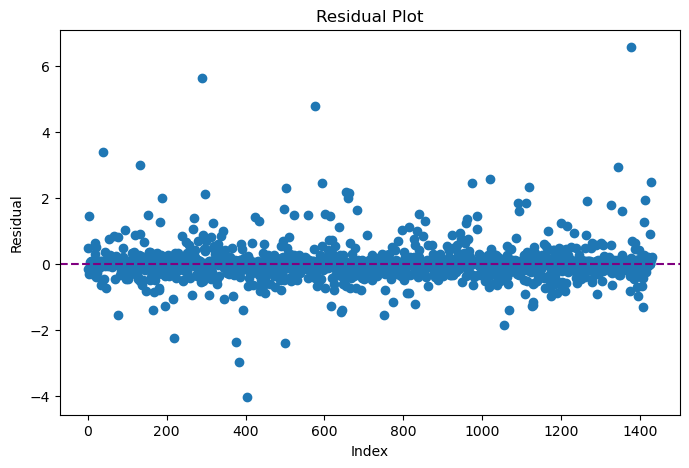

In [15]:
residuals = y_test_r - y_pred_r
plt.figure(figsize = (8,5))
plt.scatter(range(len(residuals)),residuals)
plt.axhline(0,color='purple',linestyle = '--')
plt.title('Residual Plot')
plt.xlabel('Index')
plt.ylabel('Residual')
plt.show()

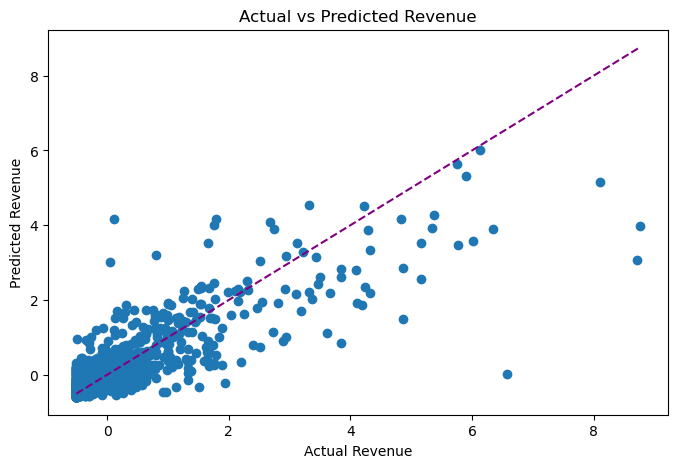

In [16]:
plt.figure(figsize = (8,5))
plt.scatter(y_test_r,y_pred_r)
plt.plot([min(y_test_r), max(y_test_r)], [min(y_test_r), max(y_test_r)], color='Purple', linestyle='--')
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

# Performance Prediction - Low , Average , High

In [17]:
perf_df = scaled_df.copy()

bins = [final_df['vote_avg'].min()-0.01,3.5,7,final_df['vote_avg'].max()+0.01]
labels = ['poor','Moderate','Excellent']
perf_df['rating_label'] = pd.cut(final_df['vote_avg'],bins = bins, labels = labels)
perf_df['rating_label_num'] = perf_df['rating_label'].map({'poor':0,'Moderate':1,'Excellent':2}).astype('Int64')

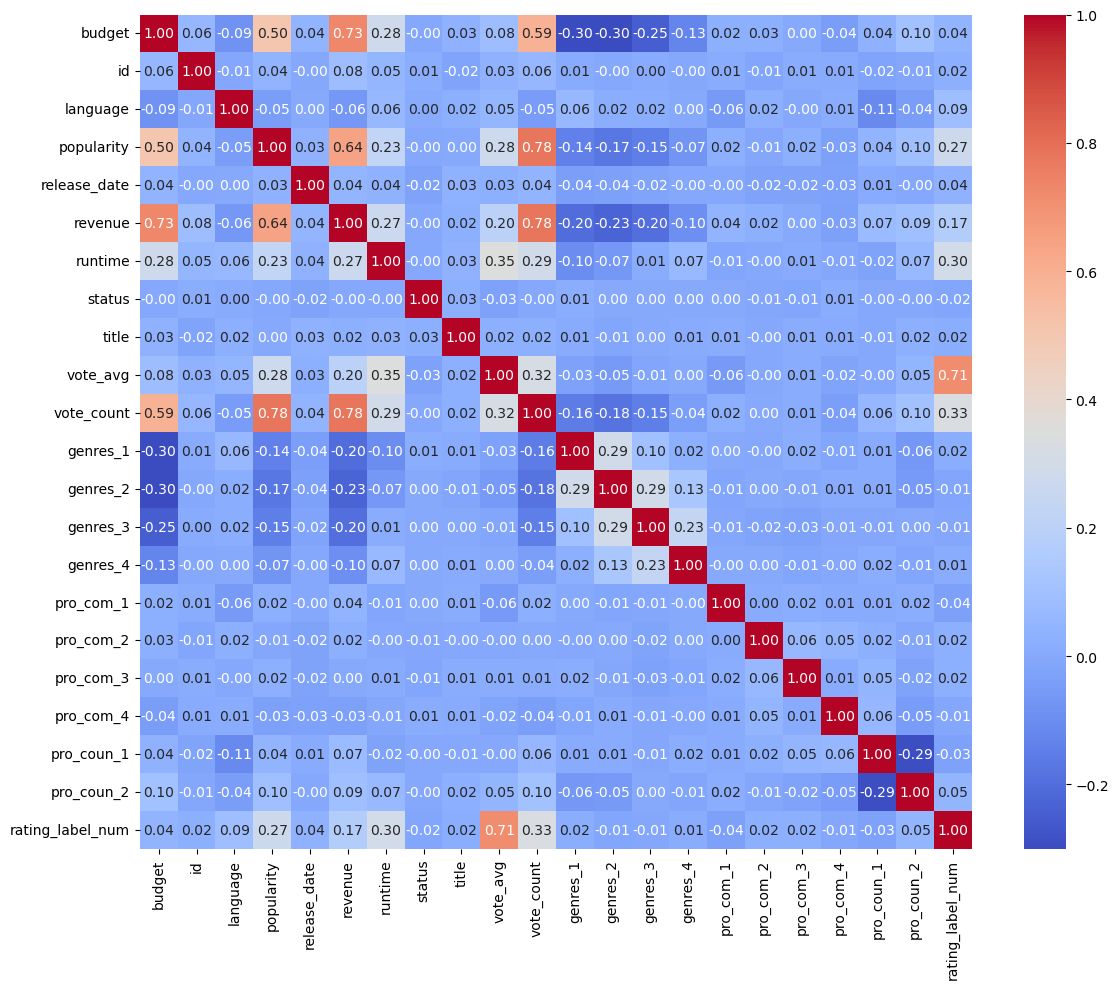

In [18]:
corr_matrix = perf_df.select_dtypes(include = 'number')

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix.corr(),cmap = 'coolwarm',fmt='.2f',annot = True)
plt.tight_layout()
plt.show()

In [20]:
perf_df['rating_label_num'].value_counts()

rating_label_num
1    3845
0     805
2     120
Name: count, dtype: int64

In [26]:
#Encoding categorical columns
lang_encoder = LabelEncoder()
rating_encoder = LabelEncoder()

perf_df['language_enc'] = lang_encoder.fit_transform(perf_df['language'])
perf_df['rating_label_num'] = rating_encoder.fit_transform(perf_df['rating_label'])

# Features and target
features = ['language_enc','popularity','revenue','runtime','vote_count']
x = perf_df[features]
y = perf_df['rating_label_num']

x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.3, random_state=1, stratify=y)
sm = SMOTE(random_state = 2)
x_tr_res, y_tr_res = sm.fit_resample(x_tr, y_tr)

print("Before SMOTE:", y_tr.value_counts())
print("After SMOTE:", y_tr_res.value_counts())
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight=None, 
    random_state=1
)

rf_model.fit(x_tr_res, y_tr_res)

# Predictions
y_pred = rf_model.predict(x_te)

# Metrics
print("Accuracy:", accuracy_score(y_te, y_pred))
print("F1 Score:", f1_score(y_te, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_te, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred))

Before SMOTE: rating_label_num
1    2691
0     564
2      84
Name: count, dtype: int64
After SMOTE: rating_label_num
1    2691
0    2691
2    2691
Name: count, dtype: int64
Accuracy: 0.7456324248777079
F1 Score: 0.7642193953091883

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.54      0.47       241
           1       0.89      0.79      0.84      1154
           2       0.25      0.61      0.35        36

    accuracy                           0.75      1431
   macro avg       0.52      0.65      0.55      1431
weighted avg       0.79      0.75      0.76      1431


Confusion Matrix:
 [[131 101   9]
 [183 914  57]
 [  3  11  22]]


'Why Random Forest?\n1. Handles non-linear relationships\n2. Works well with mixed features\n3. Resistant to overfitting\n4. Strong baseline model\n\nn_estimators=300 → number of trees (more trees = more stability)\n\nWhy SMOTE?\n\n1. Your dataset is imbalanced (some rating classes are rare)\n2. Models become biased toward majority class\n\nWhat SMOTE does:\n\n1. Creates synthetic data points for minority classes\n2. Applied only on training data to avoid data leakage\n\nstratify = y means when we send data for training and testing, there are different class - low , medium , high = so there is possibility\nmore High data can go for training and so it can affect result low and medium so Stratify send all the data in same proportion'

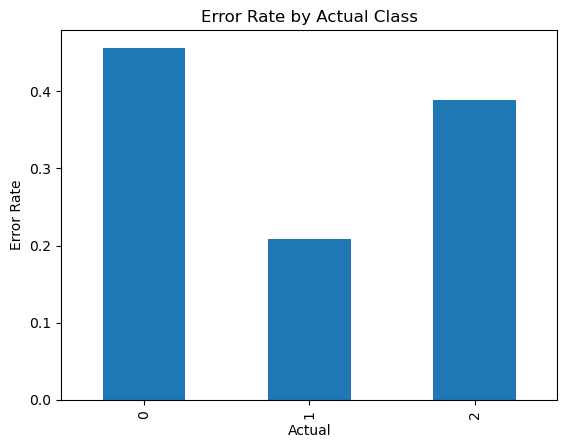

In [28]:
import pandas as pd

errors = pd.DataFrame({
    'Actual': y_te,
    'Predicted': y_pred
})

errors['Error'] = errors['Actual'] != errors['Predicted']
errors.groupby('Actual')['Error'].mean().plot(kind='bar')
plt.ylabel("Error Rate")
plt.title("Error Rate by Actual Class")
plt.show()

In [24]:
# Probability a movie is highly rated
p_high_rating = ((final_df['vote_avg'] > 7).sum() / len(final_df)) * 100

# Probability a movie has low rating and low revenue
p_low_rating_low_revenue = (
    ((final_df['vote_avg'] <= 5) & (final_df['revenue'] < final_df['revenue'].mean()))
    .sum() / len(final_df)
) * 100

# Probability a movie is either highly rated or high revenue
p_rating_or_revenue = (
    ((final_df['vote_avg'] > 7) | (final_df['revenue'] > final_df['revenue'].mean()))
    .sum() / len(final_df)
) * 100

# Conditional probability: High revenue given high rating
cond_revenue_given_rating = (
    ((final_df['revenue'] > final_df['revenue'].mean()) & (final_df['vote_avg'] > 7))
    .sum() / (final_df['vote_avg'] > 7).sum()
) * 100

# Conditional probability: High rating given high revenue
cond_rating_given_revenue = (
    ((final_df['revenue'] > final_df['revenue'].mean()) & (final_df['vote_avg'] > 7))
    .sum() / (final_df['revenue'] > final_df['revenue'].mean()).sum()
) * 100


print("Probability of High Rating:", p_high_rating)
print("Probability of Low Rating and Low Revenue:", p_low_rating_low_revenue)
print("Probability of High Rating or High Revenue:", p_rating_or_revenue)
print("Conditional Probability of High Revenue Given High Rating:", cond_revenue_given_rating)
print("Conditional Probability of High Rating Given High Revenue:", cond_rating_given_revenue)

Probability of High Rating: 16.87631027253669
Probability of Low Rating and Low Revenue: 11.572327044025158
Probability of High Rating or High Revenue: 37.735849056603776
Conditional Probability of High Revenue Given High Rating: 38.38509316770186
Conditional Probability of High Rating Given High Revenue: 23.696319018404907
